In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [104]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

np.random.seed(42)

In [105]:
data=load_breast_cancer()

X = data.data

y=data.target

X_train, X_test, y_train,y_test=train_test_split(X,y,test_size=0.2)

min = MinMaxScaler()

min.fit_transform(X_train,y_train)

min.fit(X_test)

MinMaxScaler()

In [106]:
class NeuralNetwork:

  def __init__(self,input_size,hidden_layer,output_layer):
    self.weight1 = np.random.rand(input_size,hidden_layer)
    self.weight2 = np.random.rand(hidden_layer,output_layer)
    self.bias1 = np.zeros(hidden_layer)
    self.bias2 = np.zeros(output_layer)

  def activation_function(self,y):
    return np.maximum(y,0)

  def forward(self, X_train):
    self.y=self.bias1+X_train @ self.weight1
    self.active = self.activation_function(self.y)

    self.y2=self.bias2+self.active @ self.weight2
    self.final = self.output_activation(self.y2)


    return self.final

  def output_activation(self,z):
    final = 1/(1+np.exp(z*-1))
    return final

  def relu_deri(self,y):
    return (y > 0).astype(int)

  def compute_loss(self,y_pred,y_train):
    loss = -1*(y_train*np.log(y_pred+1e-9)+(1-y_train)*np.log(1-y_pred+1e-9))
    return np.mean(loss)

  def backward(self,X_train,y_train):
    N = X_train.shape[0]

    dz2 = self.final - y_train
    dW2 = (self.active.T @ dz2) / N
    db2 = np.mean(dz2, axis=0)

    da1 = dz2 @ self.weight2.T
    dz1 = da1 * self.relu_deri(self.y)
    dW1 = (X_train.T @ dz1) / N
    db1 = np.mean(dz1, axis=0)

    return dW1, db1, dW2, db2

  def optimization(self,alpha,dW1,db1,dW2,db2):

    self.weight1 = self.weight1 - alpha * dW1
    self.weight2 = self.weight2 - alpha * dW2

    self.bias1 = self.bias1 - alpha * db1
    self.bias2 = self.bias2 - alpha * db2

  def fit(self,X_train,y_train,iteration=10000,alpha=0.001):

    self.losses = np.array([])
    for i in range(0,iteration):
      y_pred=self.forward(X_train)
      loss=self.compute_loss(y_pred,y_train)

      self.losses = np.append(self.losses,loss)

      dW1,db1,dW2,db2=self.backward(X_train,y_train)
      gradients = [dW1,db1,dW2,db2]
      self.optimization(alpha,dW1,db1,dW2,db2)

    print("The final loss is ",self.compute_loss(self.final,y_train))


  def visualize_loss(self):
    plt.title("Loss vs Iteration")
    plt.plot(np.arange(len(self.losses)),self.losses)
    plt.show()


  def predict(self,X_test):
    y_pred=self.forward(X_test)

    return y_pred.flatten()


/tmp/ipykernel_861/937708015.py:23: RuntimeWarning: overflow encountered in exp
  final = 1/(1+np.exp(z*-1))


The final loss is  0.1885209148644309


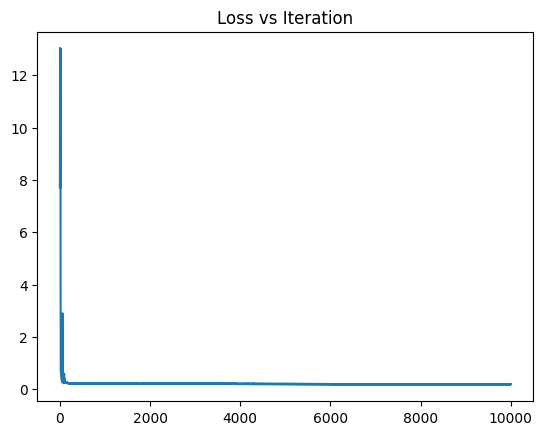

The loss of the model is 13.37815569906316 %


In [107]:
# Architecture (30,15,1)

net = NeuralNetwork(30,15,1)

y_train = y_train.reshape(-1,1)
net.fit(X_train,y_train)

net.visualize_loss()

y_pred=net.predict(X_test)

print("The loss of the model is",net.compute_loss(y_pred,y_test)*100,"%")


